# Colour Recognition with OpenCV

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(639.5), np.float64(465.5), np.float64(-0.5))

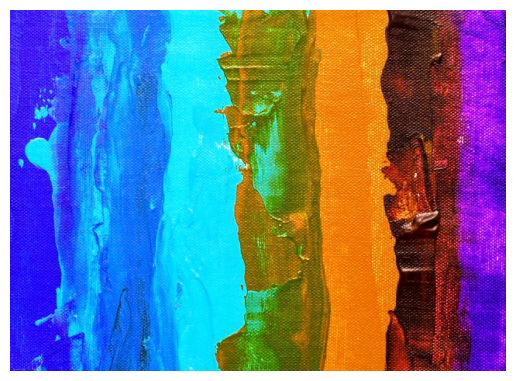

In [2]:
# 1) Resmi okuyalım
image = cv2.imread('colour.jpeg')   # veya tam yol: 'C:/.../image.jpg'
if image is None:
    raise FileNotFoundError("image.jpg bulunamadı. Dosya yolunu kontrol edin.")

plt.imshow(image)
plt.axis("off")

In [ ]:
test_image = cv2.imread("colour.jpeg")
plt.imshow(test_image)

In [3]:
# 2. BGR -> RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 3. RGB -> HSV
hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)

In [4]:
# HSV aralıkları- HSV formatı: Hue (Ton), Saturation (Doygunluk), Value (Parlaklık)
#Her renk için alt ve üst sınırları belirliyoruz.
lower_red1 = np.array([0, 120, 70])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 120, 70])
upper_red2 = np.array([180, 255, 255])

lower_blue = np.array([94, 80, 2])
upper_blue = np.array([126, 255, 255])

lower_green = np.array([40, 40, 40])
upper_green = np.array([80, 255, 255])

lower_yellow = np.array([15, 150, 150])
upper_yellow = np.array([35, 255, 255])

lower_pink = np.array([140, 50, 50])
upper_pink = np.array([170, 255, 255])

#lower_navy = np.array([100, 100, 20])
#upper_navy = np.array([120, 255, 100])

In [5]:
# 4. Maskeler 
#Görüntüdeki HSV değerlerini kontrol ederiz
#Belirlediğimiz aralığa giren pikseleler beyaz (255), diğerleri siyah (0) olur örneğin | (OR) operatörü kırmızı için iki aralığı birleştirir (0-10 ve 170-180)
mask_red = cv2.inRange(hsv, lower_red1, upper_red1) | cv2.inRange(hsv, lower_red2, upper_red2)
mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)
mask_green = cv2.inRange(hsv, lower_green, upper_green)
mask_yellow = cv2.inRange(hsv, lower_yellow, upper_yellow)
mask_pink = cv2.inRange(hsv, lower_pink, upper_pink)
#mask_navy = cv2.inRange(hsv, lower_navy, upper_navy)

# 5. Maskeleri temizle (basit morph)
#MORPH_OPEN --> Gürültüyü temizlemek için erosion + dilation uygular. Küçük beyaz noktaları (hata) siler, kenarları düzleştirir
#Kernel boyutu (5x5) etki alanını belirler
kernel = np.ones((5,5), np.uint8)
mask_red = cv2.morphologyEx(mask_red, cv2.MORPH_OPEN, kernel)
mask_blue = cv2.morphologyEx(mask_blue, cv2.MORPH_OPEN, kernel)
mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_OPEN, kernel)
mask_yellow = cv2.morphologyEx(mask_yellow, cv2.MORPH_OPEN, kernel)
mask_pink = cv2.morphologyEx(mask_pink, cv2.MORPH_OPEN, kernel)
#mask_navy = cv2.morphologyEx(mask_navy, cv2.MORPH_OPEN, kernel)

# 6. Maskeyi uygulayıp sonuçları hazırla
#Maskeyi orijinal görüntüye uygular. Maskenin beyaz olduğu yerlerde orijinal renkler kalır, maskenin siyah olduğu yerlerde siyah olur
#Örneğin res_red için sadece kırmızı renkler görülür
res_red    = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_red)
res_blue   = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_blue)
res_green  = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_green)
res_yellow = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_yellow)
res_pink   = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_pink)
#res_navy   = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_navy)

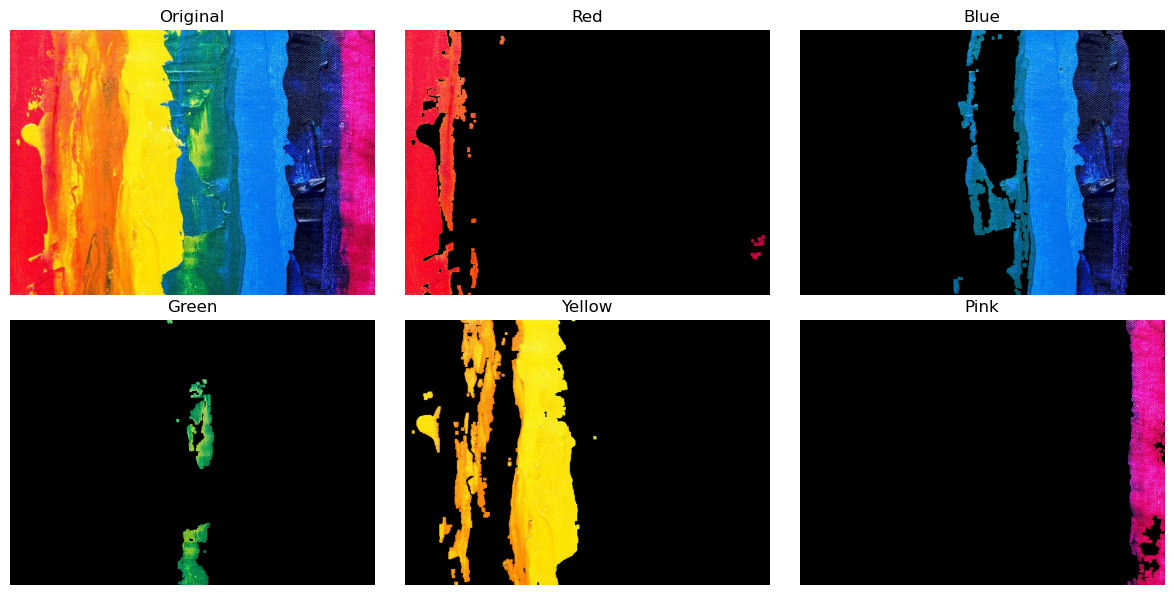

In [6]:
# 7. Görselleştir
plt.figure(figsize=(12,6))
plt.subplot(2,3,1); plt.imshow(image_rgb);    plt.title("Original"); plt.axis('off')
plt.subplot(2,3,2); plt.imshow(res_red);     plt.title("Red");      plt.axis('off')
plt.subplot(2,3,3); plt.imshow(res_blue);    plt.title("Blue");     plt.axis('off')
plt.subplot(2,3,4); plt.imshow(res_green);   plt.title("Green");    plt.axis('off')
plt.subplot(2,3,5); plt.imshow(res_yellow);  plt.title("Yellow");   plt.axis('off')
plt.subplot(2,3,6); plt.imshow(res_pink);  plt.title("Pink");   plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
#Contur işlemi ile Maskedeki beyaz bölgelerin sınırlarını bulur
#RETR_EXTERNAL: Sadece en dış konturları alır
#CHAIN_APPROX_SIMPLE: Kontur noktalarını sıkıştırır
#Bir listede tüm kontürler döndürülür

In [8]:
contours_red, _ = cv2.findContours(mask_red, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours_blue, _ = cv2.findContours(mask_blue, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours_green, _ = cv2.findContours(mask_green, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours_yellow, _ = cv2.findContours(mask_yellow, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours_pink, _ = cv2.findContours(mask_pink, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#contours_navy, _ = cv2.findContours(mask_navy, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [9]:
#output ; Her kontür için:
#1. Alanını hesapla
#2. 500 pikselden küçükse (gürültü) atla
#3. Bounding box (en küçük dikdörtgen) hesapla
#4. Görüntüye dikdörtgen çiz
#5. Etiket yazı ekle

In [10]:
output = image_rgb.copy()

def draw_boxes(contours, label, color):
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > 500:  # gürültü filtresi
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(output, (x,y), (x+w,y+h), color, 2)
            cv2.putText(output, label, (x, y-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

draw_boxes(contours_red, "Red", (255,0,0))
draw_boxes(contours_blue, "Blue", (0,0,255))
draw_boxes(contours_green, "Green", (0,255,0))
draw_boxes(contours_yellow, "Yellow", (255,255,0))
draw_boxes(contours_pink, "Pink", (255,192,203))
#draw_boxes(contours_navy, "Navy", (0,0,128))

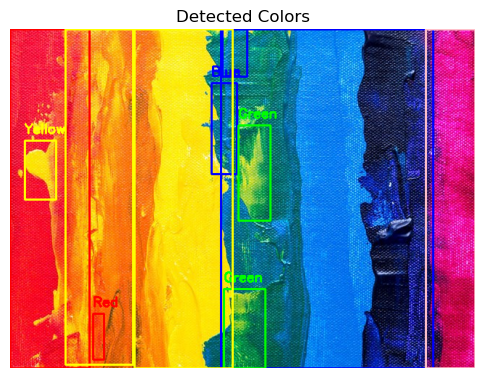

In [11]:
plt.figure(figsize=(6,6))
plt.imshow(output)
plt.title("Detected Colors")
plt.axis('off')
plt.show()

İşlem akışı: Renkli görüntü → 2. HSV'ye dönüştür → 3. Maskeyi oluştur → 4. Gürültüyü temizle → 5. Kontürları bul → 6. Kutular çiz → 7. Sonuç.           

Sonuç olarak görüntüde tüm belirli renkler algılandı ve etraflarına kutu çizilerek etiketlendi